In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix



In [3]:
df = pd.read_csv("heart.csv")


Check zeros that are really missing values


In [4]:
print("Cholesterol zeros:", (df["Cholesterol"] == 0).sum())
print("RestingBP zeros:", (df["RestingBP"] == 0).sum())



Cholesterol zeros: 172
RestingBP zeros: 1


Separate features and target

In [5]:
X = df.drop("HeartDisease", axis=1)
y = df["HeartDisease"]


Mark impossible zeros as missing


In [6]:
X["Cholesterol"] = X["Cholesterol"].replace(0, np.nan)
X["RestingBP"] = X["RestingBP"].replace(0, np.nan)


Convert text columns to 0/1 columns


In [7]:
X = pd.get_dummies(X, drop_first=True, dtype=int)


Split into train and test


In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)



Fill missing values using the TRAIN median only


In [9]:
medians = X_train.median()
X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

Scale the features (fit on train, apply to test)


In [10]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

Train logistic regression

In [11]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train_s, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


Predict and evaluate


In [12]:
pred = model.predict(X_test_s)
print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))
print(confusion_matrix(y_test, pred))

Accuracy: 0.8913043478260869
              precision    recall  f1-score   support

           0       0.89      0.87      0.88        82
           1       0.89      0.91      0.90       102

    accuracy                           0.89       184
   macro avg       0.89      0.89      0.89       184
weighted avg       0.89      0.89      0.89       184

[[71 11]
 [ 9 93]]


mathematical intuition of logistic regression


Linear Regression on Heart Data (HeartDisease yes/no)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay



Train linear regression

In [14]:
lin_model = LinearRegression()
lin_model.fit(X_train_s, y_train)


,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


Linear regression gives a raw number for each patient, not a class


In [15]:
lin_raw = lin_model.predict(X_test_s)


Turn the number into a class using 0.5 as the cut-off


In [16]:
lin_pred = (lin_raw >= 0.5).astype(int)


Evaluate

Linear regression accuracy: 0.875
              precision    recall  f1-score   support

           0       0.87      0.84      0.86        82
           1       0.88      0.90      0.89       102

    accuracy                           0.88       184
   macro avg       0.87      0.87      0.87       184
weighted avg       0.87      0.88      0.87       184

[[69 13]
 [10 92]]


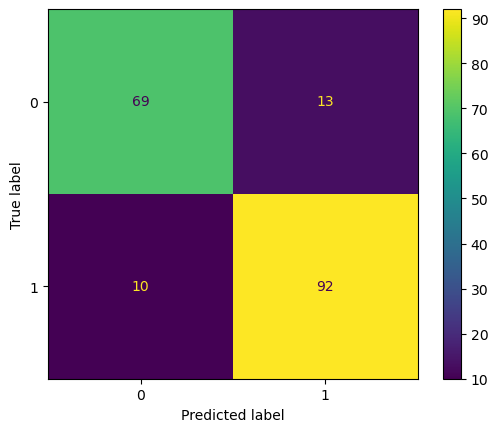

In [17]:
print("Linear regression accuracy:", accuracy_score(y_test, lin_pred))
print(classification_report(y_test, lin_pred))
print(confusion_matrix(y_test, lin_pred))
ConfusionMatrixDisplay.from_predictions(y_test, lin_pred)


In [18]:
print("First 10 raw outputs:", lin_raw[:10].round(2))
print("Min:", lin_raw.min(), " Max:", lin_raw.max())
print("Outputs below 0:", (lin_raw < 0).sum())
print("Outputs above 1:", (lin_raw > 1).sum())

First 10 raw outputs: [ 0.95  0.17  0.98  0.56  0.32  0.5  -0.04  0.57 -0.03  1.08]
Min: -0.14683621268990976  Max: 1.1453381908152471
Outputs below 0: 15
Outputs above 1: 14


In [19]:
print("Logistic regression accuracy:", accuracy_score(y_test, pred))
print("Linear regression accuracy:  ", accuracy_score(y_test, lin_pred))

Logistic regression accuracy: 0.8913043478260869
Linear regression accuracy:   0.875


Accuracy	0.891 (164/184 correct)	0.875 (161/184 correct)

Missed patients (FN)	9	10

False alarms (FP)	    11   13

Recall (patients)	   0.91	  0.90

Precision (patients)	0.89   0.88

The more important finding: invalid outputs

Linear regression is supposed to give probabilities for a yes/no question, and it broke the rules:

15 outputs were below 0 (the lowest was about -0.15)
14 outputs were above 1 (the highest was about 1.15)

That means 29 of 184 predictions (about 16%) were impossible probabilities, such as "-15% chance of disease". It still reached 87.5% accuracy because the 0.5 cut-off only cares which side of 0.5 a value falls on. But the numbers are not trustworthy as probabilities. Logistic regression's sigmoid guarantees every output stays between 0 and 1, which is the main reason to choose it for classification.

In [20]:
probs = model.predict_proba(X_test_s)[:, 1]
print("Logistic min:", probs.min(), " max:", probs.max())

Logistic min: 0.008686578564986233  max: 0.9909682298218899


In [21]:
import joblib

joblib.dump(model, "heart_model.pkl")                         # logistic regression 
joblib.dump(scaler, "scaler.pkl")                             # the fitted scaler
joblib.dump(list(X_train.columns), "feature_columns.pkl")     # exact column order after get_dummies
joblib.dump(medians, "medians.pkl")                           # medians used to fill missing values

['medians.pkl']

In [22]:
print(list(X_train.columns))

['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'Sex_M', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_Normal', 'RestingECG_ST', 'ExerciseAngina_Y', 'ST_Slope_Flat', 'ST_Slope_Up']
